# Simplecticidad de `flow` y `adjoint_flow` en GC

Este notebook calcula mediante diferencias finitas las matrices jacobianas de cada etapa interna BM4 y estudia el defecto simpléctico

$$D(J)=J^T\Omega J-\Omega.$$

Una transformación simpléctica satisface $D(J)=0$ y $\det(J)=1$. Para las actualizaciones triangulares GC, $\Omega$ empareja de forma cruzada las dos copias internas. El observador imprime estas métricas durante la integración y guarda las matrices completas en bloques comprimidos. Para este diagnóstico se usa `check_energy=False`: el estado observado contiene exactamente las dos copias físicas `[x_1, y_1, x_2, y_2]`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np


def find_project_root(start):
    """Find the project whether Jupyter starts at the root or notebook folder."""
    location = Path(start).resolve()
    for candidate in (location, *location.parents):
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise RuntimeError('No se encontró la raíz del proyecto.')


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from classes import Potential, SystemGC, TrajectoryGC
from research.symplecticity import SymplecticityObserver

NOTEBOOK_PATH = (
    PROJECT_ROOT / 'notebooks' / 'developements' / 'study_gc_symplecticity.ipynb'
)

In [2]:
# Un único punto mantiene el jacobiano interno en 4 x 4 y facilita su lectura.
potential = Potential.random(
    A=0.7,
    M=8,
    nx=32,
    ny=32,
    seed=27,
    interpolation_order=5,
)
x0 = potential.grid.xmin + potential.grid.period / 2
y0 = potential.grid.ymin + potential.grid.period / 2
trajectory = TrajectoryGC.from_components(
    x=np.asarray([x0]),
    y=np.asarray([y0]),
    rho=0.3,
)

# Cambia este valor para comparar el acoplamiento nulo con frecuencias positivas.
coupling_frequency = 0.0
system = SystemGC(
    potential,
    trajectory,
    coupling_frequency=coupling_frequency,
)

In [3]:
# Cada paso BM4 genera doce observaciones. Un bloque de doce matrices
# corresponde aquí a un paso completo de la composición.
with SymplecticityObserver(
    notebook_path=NOTEBOOK_PATH,
    particle_count=trajectory.particle_count(trajectory.state),
    project_root=PROJECT_ROOT,
    block_name='symplecticity',
    sample_every=1,
    chunk_size=12,
    verbose=True,
    metadata={
        'coupling_frequency': coupling_frequency,
        'rho': trajectory.rho,
        'potential_seed': 27,
        'integration_step': 0.02,
    },
) as observer:
    solution = system.simulate(
        step=0.02,
        t_span=(0.0, 0.04),
        n_save_step=3,
        check_energy=False,
        progress=False,
        stage_observer=observer,
    )

records = observer.records
output_blocks = observer.output_blocks
print(f'Observaciones: {len(records)}')
print(f'Salida: {observer.output_directory}')
for block in output_blocks:
    print(
        f'Bloque {block.index:05d}: {block.sample_count} matrices -> ' 
        f'{block.jacobians_path.name}'
    )

[symplecticity] step=00000 stage=00 adjoint_flow relative_defect=9.105e-12 |det(J)-1|=1.185e-11
[symplecticity] step=00000 stage=01 flow         relative_defect=1.633e-11 |det(J)-1|=2.507e-11
[symplecticity] step=00000 stage=02 adjoint_flow relative_defect=1.441e-11 |det(J)-1|=3.927e-12
[symplecticity] step=00000 stage=03 flow         relative_defect=9.431e-12 |det(J)-1|=1.551e-12
[symplecticity] step=00000 stage=04 adjoint_flow relative_defect=8.204e-12 |det(J)-1|=2.941e-12
[symplecticity] step=00000 stage=05 flow         relative_defect=1.192e-11 |det(J)-1|=1.102e-11
[symplecticity] step=00000 stage=06 adjoint_flow relative_defect=1.433e-11 |det(J)-1|=1.808e-11
[symplecticity] step=00000 stage=07 flow         relative_defect=1.121e-11 |det(J)-1|=1.565e-11
[symplecticity] step=00000 stage=08 adjoint_flow relative_defect=1.365e-11 |det(J)-1|=6.039e-12
[symplecticity] step=00000 stage=09 flow         relative_defect=1.631e-11 |det(J)-1|=1.534e-11
[symplecticity] step=00000 stage=10 adjo

## Organización de la salida

La ruta se deriva del notebook y de la fecha de ejecución:

```text
outputs/developements/study_gc_symplecticity/AAAA-MM-DD/
├── symplecticity_summary_00000.csv
├── symplecticity_jacobians_00000.npz
└── symplecticity_metadata_00000.json
```

Si se vuelve a ejecutar el notebook, los índices continúan y los resultados anteriores no se sobrescriben.

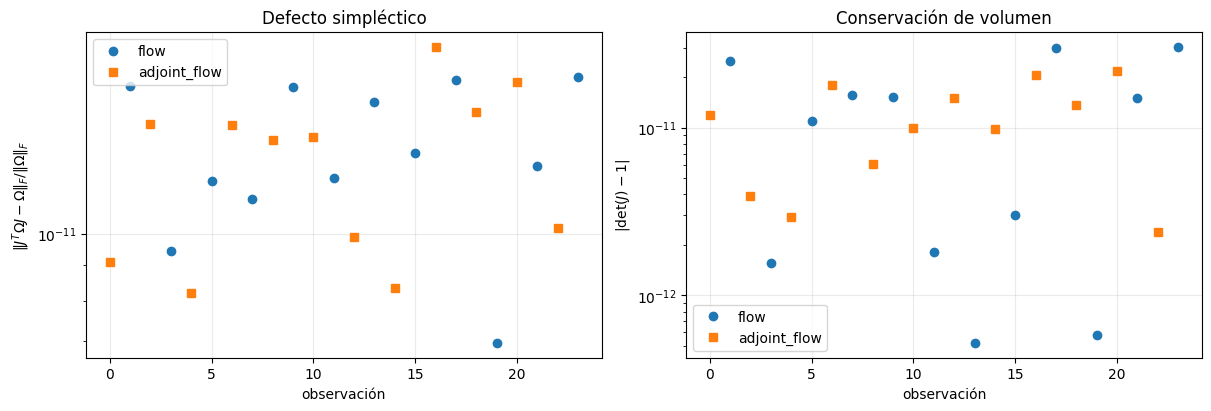

In [4]:
observation_indices = np.asarray([record.observation_index for record in records])
relative_defects = np.asarray([record.relative_defect for record in records])
determinant_errors = np.asarray([record.determinant_error for record in records])
flow_names = np.asarray([record.flow_name for record in records])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for flow_name, marker in (('flow', 'o'), ('adjoint_flow', 's')):
    selected = flow_names == flow_name
    axes[0].semilogy(
        observation_indices[selected],
        relative_defects[selected],
        marker=marker,
        ls='none',
        label=flow_name,
    )
    axes[1].semilogy(
        observation_indices[selected],
        determinant_errors[selected],
        marker=marker,
        ls='none',
        label=flow_name,
    )

axes[0].set(title='Defecto simpléctico', xlabel='observación', ylabel=r'$\|J^T\Omega J-\Omega\|_F/\|\Omega\|_F$')
axes[1].set(title='Conservación de volumen', xlabel='observación', ylabel=r'$|\det(J)-1|$')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.show()

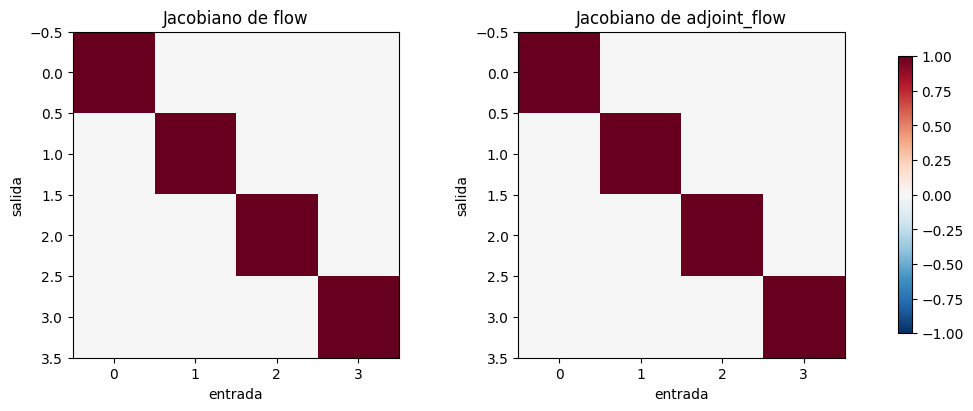

In [5]:
# Visualiza una matriz de cada tipo desde el último bloque persistido.
with np.load(output_blocks[-1].jacobians_path) as stored:
    jacobians = stored['jacobians'].copy()
    stored_flow_names = stored['flow_names'].astype(str)

selected_indices = [
    int(np.flatnonzero(stored_flow_names == flow_name)[0])
    for flow_name in ('flow', 'adjoint_flow')
]
limit = max(np.max(np.abs(jacobians[index])) for index in selected_indices)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for axis, flow_name, index in zip(
    axes, ('flow', 'adjoint_flow'), selected_indices, strict=True
):
    image = axis.imshow(
        jacobians[index],
        cmap='RdBu_r',
        vmin=-limit,
        vmax=limit,
    )
    axis.set(title=f'Jacobiano de {flow_name}', xlabel='entrada', ylabel='salida')
fig.colorbar(image, ax=axes, shrink=0.85)
plt.show()